In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directories
os.makedirs('data', exist_ok=True)
os.makedirs('visuals', exist_ok=True)

def fetch_bdapi_metadata(study_id):
    """
    Uses the NASA BDAPI v2 endpoint to fetch ISA-Tab metadata directly into a DataFrame.
    """
    print(f"Querying BDAPI Metadata for OSD-{study_id}...")
    
    # Using the exact endpoint specified in the OSDR documentation
    url = f"https://visualization.osdr.nasa.gov/biodata/api/v2/query/metadata/?id.accession=OSD-{study_id}"
    
    try:
        # The API natively returns a CSV formatted response, which pandas can read directly from the URL!
        df = pd.read_csv(url)
        
        # Add a helper column so we know which dataset this belongs to when combined
        df['Dataset_ID'] = f"OSD-{study_id}"
        
        # Clean up column names to avoid trailing spaces from the API
        df.columns = [c.strip() for c in df.columns]
        
        print(f" -> Successfully loaded {len(df)} metadata records for OSD-{study_id}.")
        return df
        
    except Exception as e:
        print(f" -> Error fetching OSD-{study_id}: {e}")
        return pd.DataFrame() # Return empty DataFrame on failure

# 1. Fetch the exact metadata for both Gut Microbiome datasets
df_osd249_meta = fetch_bdapi_metadata("249")
df_osd466_meta = fetch_bdapi_metadata("466")

# Safety Check: If both failed, stop execution to prevent KeyError
if df_osd249_meta.empty and df_osd466_meta.empty:
    raise ValueError("The BDAPI returned no data for both datasets. Please check your internet connection or API status.")

# 2. Save strictly named CSV files for your partner
csv_249 = 'data/df_osd249_metadata.csv'
csv_466 = 'data/df_osd466_metadata.csv'

if not df_osd249_meta.empty:
    df_osd249_meta.to_csv(csv_249, index=False)
if not df_osd466_meta.empty:
    df_osd466_meta.to_csv(csv_466, index=False)

print(f"\nSaved Metadata Tables to disk:")
print(f" - {csv_249}")
print(f" - {csv_466}")

# 3. Analyze what Data Types are available to download next
# We will combine them to look at the 'file.datatype' or 'file.datatype' column
df_combined_meta = pd.concat([df_osd249_meta, df_osd466_meta], ignore_index=True)

# The BDAPI docs note it could be 'file.data type' or 'file.datatype'. Let's find which one exists.
datatype_col = 'file.datatype' if 'file.datatype' in df_combined_meta.columns else 'file.data type'

if datatype_col in df_combined_meta.columns:
    type_counts = df_combined_meta.groupby(['Dataset_ID', datatype_col]).size().reset_index(name='Count')
    
    # 4. Create Visualization of Available Data Types
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    sns.barplot(
        data=type_counts, 
        y=datatype_col, 
        x='Count', 
        hue='Dataset_ID', 
        palette=['#1E3A8A', '#0D9488'], # Spaceflight Blue, GC Teal
        ax=ax
    )
    
    ax.set_title('Available Biological Data Types via BDAPI', weight='bold', pad=15)
    ax.set_xlabel('Number of Sample Records', weight='bold')
    ax.set_ylabel('Data Type', weight='bold')
    
    # Add labels to bars
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
        
    plt.tight_layout()
    fig_path = 'visuals/BDAPI_Available_Data_Types.png'
    plt.savefig(fig_path, bbox_inches='tight')
    print(f"\nVisualization saved to {fig_path}")
    
    print("\nAvailable Data Types found:")
    print(type_counts)
    
else:
    print(f"\nNote: The column '{datatype_col}' was not found in the metadata. The datasets might be structured differently.")
    print("Available columns to query:", list(df_combined_meta.columns))

Querying BDAPI Metadata for OSD-249...
 -> Successfully loaded 222 metadata records for OSD-249.
Querying BDAPI Metadata for OSD-466...
 -> Successfully loaded 62 metadata records for OSD-466.

Saved Metadata Tables to disk:
 - data/df_osd249_metadata.csv
 - data/df_osd466_metadata.csv

Note: The column 'file.data type' was not found in the metadata. The datasets might be structured differently.
Available columns to query: ['id.accession', 'id.assay name', 'id.sample name', 'Dataset_ID']


In [1]:
df_osd249_meta

NameError: name 'df_osd249_meta' is not defined

# OSD-466 Extraction

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style and create output directory
sns.set_theme(style="whitegrid")
OUTPUT_DIR = "OSD-466_Analysis_Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[1/4] Loading metadata and filtering WT Flight (FLT) vs Ground Control (GC)...")
meta_df = pd.read_csv('data/df_osd466_metadata.csv')

def parse_sample_name(name):
    parts = str(name).split('_')
    if len(parts) >= 5:
        return {
            'sample_name': name,
            'condition': parts[2],  # FLT, GC, BSL, VIV
            'genotype': parts[3],   # WT, KO
        }
    return None

parsed_meta = pd.DataFrame([parse_sample_name(x) for x in meta_df['id.sample name']])
merged_meta = pd.concat([meta_df, parsed_meta], axis=1)

# Filter: WT only, FLT or GC only (drops BSL, VIV, KO)
target_meta = merged_meta[
    (merged_meta['genotype'].str.upper() == 'WT') & 
    (merged_meta['condition'].isin(['FLT', 'GC']))
].copy()

flt_samples = target_meta[target_meta['condition'] == 'FLT']['id.sample name'].tolist()
gc_samples = target_meta[target_meta['condition'] == 'GC']['id.sample name'].tolist()
target_samples = flt_samples + gc_samples

print(f"--> Confirmed target samples: {len(flt_samples)} FLT, {len(gc_samples)} GC")

print("[2/4] Loading taxonomic abundance table and filtering species-level profiles...")
tsv_path = 'data/GLDS-466_GMetagenomics_Metaphlan-taxonomy_GLmetagenomics.tsv'

if not os.path.exists(tsv_path):
    raise FileNotFoundError(f"Please place '{tsv_path}' in your current working directory.")

# Read MetaPhlAn TSV file, skipping comment lines with comment='#'
abundance_df = pd.read_csv(tsv_path, sep='\t', comment='#')

# Set clade_name as the index
if 'clade_name' in abundance_df.columns:
    abundance_df = abundance_df.set_index('clade_name')

# Filter for species-level taxonomic signatures (|s__)
species_df = abundance_df[abundance_df.index.str.contains(r'\|s__')].copy()

def clean_taxa_name(name):
    parts = name.split('|')
    for p in reversed(parts):
        if p.startswith('s__'):
            return p.replace('s__', '').replace('_', ' ')
    return name

species_df.index = [clean_taxa_name(idx) for idx in species_df.index]

# Filter columns to match our available target samples
available_samples = [s for s in target_samples if s in species_df.columns]
filtered_species = species_df[available_samples]

# Normalize to percentage relative abundance per sample
rel_abundance = filtered_species.div(filtered_species.sum(axis=0), axis=1) * 100

print("[3/4] Computing Top 10 most abundant species per individual and group means...")
ind_records = []
for sample in available_samples:
    group = 'FLT' if sample in flt_samples else 'GC'
    top10 = rel_abundance[sample].sort_values(ascending=False).head(10)
    for taxa, val in top10.items():
        ind_records.append({
            'Sample_ID': sample,
            'Group': group,
            'Taxa': taxa,
            'Relative_Abundance_Pct': val
        })

df_ind_top10 = pd.DataFrame(ind_records)
df_ind_top10.to_csv(f"{OUTPUT_DIR}/OSD-466_Individual_Top10_Abundance.csv", index=False)

# Group means comparison
active_flt = [s for s in flt_samples if s in available_samples]
active_gc = [s for s in gc_samples if s in available_samples]

mean_abundance = pd.DataFrame({
    'FLT_Mean': rel_abundance[active_flt].mean(axis=1),
    'GC_Mean': rel_abundance[active_gc].mean(axis=1)
})

top10_flt = set(mean_abundance['FLT_Mean'].sort_values(ascending=False).head(10).index)
top10_gc = set(mean_abundance['GC_Mean'].sort_values(ascending=False).head(10).index)
combined_top = list(top10_flt.union(top10_gc))

df_group_comp = mean_abundance.loc[combined_top].reset_index()

# Ensure standard column naming for the taxonomy/taxa identifier
if 'clade_name' in df_group_comp.columns:
    df_group_comp.rename(columns={'clade_name': 'Taxa'}, inplace=True)
elif 'index' in df_group_comp.columns:
    df_group_comp.rename(columns={'index': 'Taxa'}, inplace=True)

df_group_comp.to_csv(f"{OUTPUT_DIR}/OSD-466_Group_Mean_Comparison.csv", index=False)

print("[4/4] Generating visualization charts...")
plt.figure(figsize=(12, 7))

# Dynamic check and identifier resolution for melting
if 'Taxa' not in df_group_comp.columns:
    df_group_comp = df_group_comp.reset_index()

taxa_col = None
for col in df_group_comp.columns:
    if str(col).lower() in ['taxa', 'taxonomy', 'species', 'genus', 'clade']:
        taxa_col = col
        break

if taxa_col is None:
    taxa_col = df_group_comp.columns[0]

df_melted = df_group_comp.melt(id_vars=taxa_col, var_name='Group', value_name='Mean_Abundance_Pct')

if taxa_col != 'Taxa':
    df_melted = df_melted.rename(columns={taxa_col: 'Taxa'})

df_melted['Group'] = df_melted['Group'].map({'FLT_Mean': 'Flight (FLT)', 'GC_Mean': 'Ground Control (GC)'})

sns.barplot(
    data=df_melted, 
    x='Mean_Abundance_Pct', 
    y='Taxa', 
    hue='Group', 
    palette={'Flight (FLT)': 'darkorange', 'Ground Control (GC)': 'steelblue'}
)
plt.title('Top Dominant Microbial Species: WT Flight vs Ground Control (OSD-466)')
plt.xlabel('Mean Relative Abundance (%)')
plt.ylabel('Species')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/OSD-466_Group_Comparison_Plot.png", dpi=300)
plt.close()

print(f"Success! All outputs saved cleanly in '{OUTPUT_DIR}/'.")

[1/4] Loading metadata and filtering WT Flight (FLT) vs Ground Control (GC)...
--> Confirmed target samples: 3 FLT, 5 GC
[2/4] Loading taxonomic abundance table and filtering species-level profiles...
[3/4] Computing Top 10 most abundant species per individual and group means...
[4/4] Generating visualization charts...
Success! All outputs saved cleanly in 'OSD-466_Analysis_Outputs/'.


In [3]:
species_df.head(5)

,RR10_FCS_BSL_KO_B10,RR10_FCS_BSL_KO_B12,RR10_FCS_BSL_KO_B14,RR10_FCS_BSL_KO_B16,RR10_FCS_BSL_KO_B18,RR10_FCS_BSL_KO_B20,RR10_FCS_BSL_KO_B2,RR10_FCS_BSL_KO_B4,RR10_FCS_BSL_KO_B6,RR10_FCS_BSL_KO_B8,...,RR10_FCS_VIV_WT_V12,RR10_FCS_VIV_WT_V1,RR10_FCS_VIV_WT_V2,RR10_FCS_VIV_WT_V3,RR10_FCS_VIV_WT_V4,RR10_FCS_VIV_WT_V5,RR10_FCS_VIV_WT_V6,RR10_FCS_VIV_WT_V7,RR10_FCS_VIV_WT_V8,RR10_FCS_VIV_WT_V9
Akkermansia muciniphila,13.463271,5.022410,9.844930,17.294876,39.926301,22.470967,15.121516,25.139621,22.625256,0.173943,...,0.079216,0.036947,0.363855,0.000000,0.381130,0.024388,0.000000,0.059820,0.056571,0.055672
GGB27918 SGB40356,7.284338,3.386359,3.881127,2.686070,5.103520,7.959150,3.292596,9.093639,3.771145,4.814456,...,1.714858,1.863458,5.153905,3.512490,3.776497,4.434399,3.205862,6.874314,6.137821,2.972852
GGB27875 SGB40309,4.976224,11.084100,6.020500,1.223230,6.868462,0.126297,1.683229,5.552988,3.112187,0.000000,...,1.536531,0.849001,6.633824,1.065460,2.806584,4.466229,3.427266,4.032644,3.565415,1.426257
GGB24102 SGB35895,3.882620,4.287449,1.041206,3.379921,2.936136,19.616171,0.308023,5.379176,1.418696,5.781726,...,6.308563,10.103265,13.130377,8.900002,15.100145,10.558460,28.386515,14.494704,15.108413,8.310980
Lachnospiraceae bacterium,3.828431,4.316771,0.959598,0.155100,1.095974,3.579886,0.497165,0.769682,1.754016,1.581851,...,0.647769,3.489723,0.818646,1.403924,0.293262,1.549240,0.372572,0.130680,0.426118,1.382403


# OSD-249 Analysis

In [9]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

OUTPUT_DIR = "OSD-249_Analysis_Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Native Benjamini-Hochberg FDR implementation
def benjamini_hochberg(p_values):
    p_vals = np.asarray(p_values)
    n = len(p_vals)
    if n == 0:
        return np.array([]), np.array([], dtype=bool)
    
    sorted_indices = np.argsort(p_vals)
    sorted_p_values = p_vals[sorted_indices]
    
    q_values = np.zeros(n)
    cummin = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q_val = sorted_p_values[i] * n / rank
        cummin = min(cummin, q_val)
        q_values[i] = cummin
    
    original_q_values = np.zeros(n)
    original_q_values[sorted_indices] = np.clip(q_values, 0, 1.0)
    reject = original_q_values < 0.05
    return original_q_values, reject

# Direct column header parser for FLT/GC and LAR/ISS-T cohorts
def parse_cohort_columns(tsv_columns):
    cohort_map = {'FLT_LAR': [], 'GC_LAR': [], 'FLT_ISS-T': [], 'GC_ISS-T': []}
    
    for col in tsv_columns:
        if col.lower() in ['clade_name', 'ncbi_tax_id', 'taxonomy']:
            continue
            
        col_clean = col.upper().replace('-', '_')
        
        # Determine Condition
        cond = None
        if '_FLT_' in col_clean or '_FLT' in col_clean or 'FLT_' in col_clean:
            cond = 'FLT'
        elif '_GC_' in col_clean or '_GC' in col_clean or 'GC_' in col_clean:
            cond = 'GC'
            
        # Determine Duration
        dur = None
        if 'ISS' in col_clean:
            dur = 'ISS-T'
        elif 'LAR' in col_clean:
            dur = 'LAR'
            
        if cond and dur:
            key = f"{cond}_{dur}"
            cohort_map[key].append(col)
            
    return cohort_map

technologies = ['Swift1S', 'NxtaFlex', 'LoopG']
durations = ['LAR', 'ISS-T']

for tech in technologies:
    tsv_path = f'data/GLDS-249_GMetagenomics_{tech}_Metaphlan-taxonomy.tsv'
    if not os.path.exists(tsv_path):
        print(f"\n[WARNING] File not found: {tsv_path}. Skipping this technology...")
        continue
        
    print(f"\n--- Processing Technology: {tech} ---")
    abundance_df = pd.read_csv(tsv_path, sep='\t', comment='#')
    
    if 'clade_name' in abundance_df.columns:
        abundance_df = abundance_df.set_index('clade_name')
        
    # Isolate species-level rows (|s__)
    species_df = abundance_df[abundance_df.index.str.contains(r'\|s__')].copy()
    species_df.index = [idx.split('|s__')[-1].replace('_', ' ') for idx in species_df.index]
    species_df = species_df.groupby(species_df.index).sum()

    # Automatically identify sample columns from TSV headers
    cohort_columns = parse_cohort_columns(species_df.columns)

    for duration in durations:
        print(f"  -> Analyzing Duration: {duration}")
        
        avail_flt = cohort_columns.get(f'FLT_{duration}', [])
        avail_gc = cohort_columns.get(f'GC_{duration}', [])
        
        if not avail_flt or not avail_gc:
            print(f"     [!] Missing samples (FLT: {len(avail_flt)}, GC: {len(avail_gc)}). Skipping.")
            continue
            
        print(f"     [+] Detected {len(avail_flt)} FLT and {len(avail_gc)} GC sample columns.")
        
        # Ensure numeric types and normalize relative abundance (%)
        numeric_cols = avail_flt + avail_gc
        for col in numeric_cols:
            species_df[col] = pd.to_numeric(species_df[col], errors='coerce').fillna(0)
            
        rel_abund = species_df[numeric_cols].div(species_df[numeric_cols].sum(axis=0), axis=1) * 100
        
        results = []
        for species in rel_abund.index:
            flt_vals = rel_abund.loc[species, avail_flt].values
            gc_vals = rel_abund.loc[species, avail_gc].values
            
            mean_flt = np.mean(flt_vals)
            mean_gc = np.mean(gc_vals)
            
            if mean_flt == 0 and mean_gc == 0:
                continue
                
            stat, pval = mannwhitneyu(flt_vals, gc_vals, alternative='two-sided')
            results.append({
                'Species': species,
                'Mean_FLT': mean_flt,
                'Mean_GC': mean_gc,
                'Log2_Fold_Change': np.log2((mean_flt + 1e-6) / (mean_gc + 1e-6)),
                'p_value': pval
            })
            
        df_res = pd.DataFrame(results)
        if df_res.empty:
            continue
            
        q_vals, reject = benjamini_hochberg(df_res['p_value'])
        df_res['p_adjusted_FDR'] = q_vals
        df_res['Significant_FDR_0.05'] = reject
        df_res = df_res.sort_values(by='p_value')
        
        # Save differential abundance outputs
        prefix = f"OSD-249_{tech}_{duration}"
        csv_out = f"{OUTPUT_DIR}/{prefix}_Differential_Abundance.csv"
        df_res.to_csv(csv_out, index=False)
        
        # Plot top 10 shifted taxa
        top10 = df_res.head(10)['Species'].tolist()
        plot_data = rel_abund.loc[top10, numeric_cols].reset_index()
        plot_data = plot_data.melt(id_vars='index', var_name='Sample', value_name='Relative_Abundance')
        plot_data['Condition'] = plot_data['Sample'].apply(lambda x: 'Flight (FLT)' if x in avail_flt else 'Ground Control (GC)')
        plot_data.rename(columns={'index': 'Species'}, inplace=True)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(data=plot_data, x='Relative_Abundance', y='Species', hue='Condition', errorbar='se', palette=['#E74C3C', '#3498DB'])
        plt.title(f"Top 10 Shifted Taxa: {tech} Protocol | Mission: {duration}\n(FLT n={len(avail_flt)}, GC n={len(avail_gc)})")
        plt.xlabel("Mean Relative Abundance (%)")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/{prefix}_Top10_Barplot.png", dpi=300)
        plt.close()

print(f"\nPipeline execution complete. All output CSVs and plots are stored in '{OUTPUT_DIR}'.")


--- Processing Technology: Swift1S ---
  -> Analyzing Duration: LAR
     [+] Detected 9 FLT and 7 GC sample columns.
  -> Analyzing Duration: ISS-T
     [+] Detected 7 FLT and 9 GC sample columns.

--- Processing Technology: NxtaFlex ---
  -> Analyzing Duration: LAR
     [+] Detected 9 FLT and 7 GC sample columns.
  -> Analyzing Duration: ISS-T
     [+] Detected 7 FLT and 9 GC sample columns.

--- Processing Technology: LoopG ---
  -> Analyzing Duration: LAR
     [+] Detected 5 FLT and 5 GC sample columns.
  -> Analyzing Duration: ISS-T
     [+] Detected 5 FLT and 5 GC sample columns.

Pipeline execution complete. All output CSVs and plots are stored in 'OSD-249_Analysis_Outputs'.


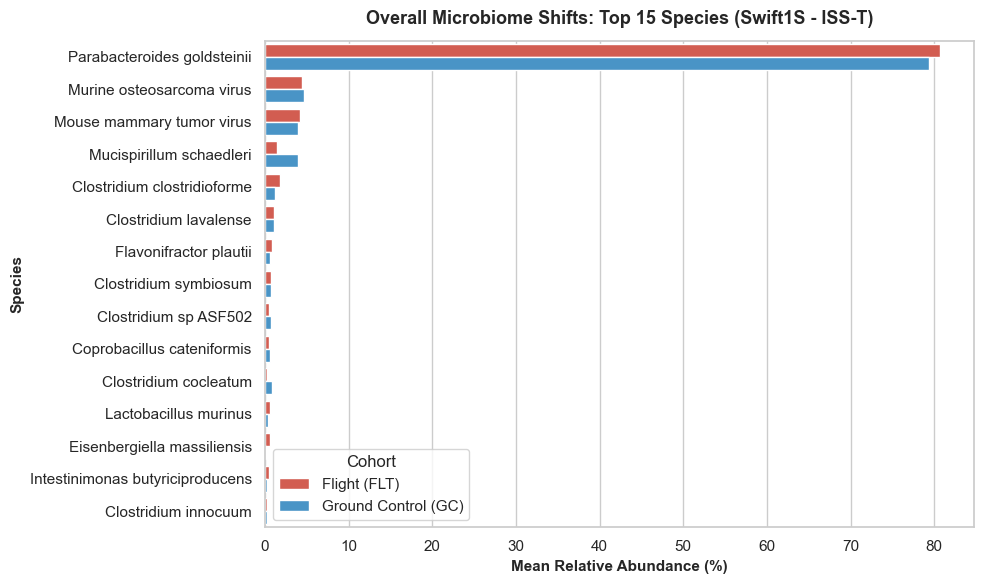

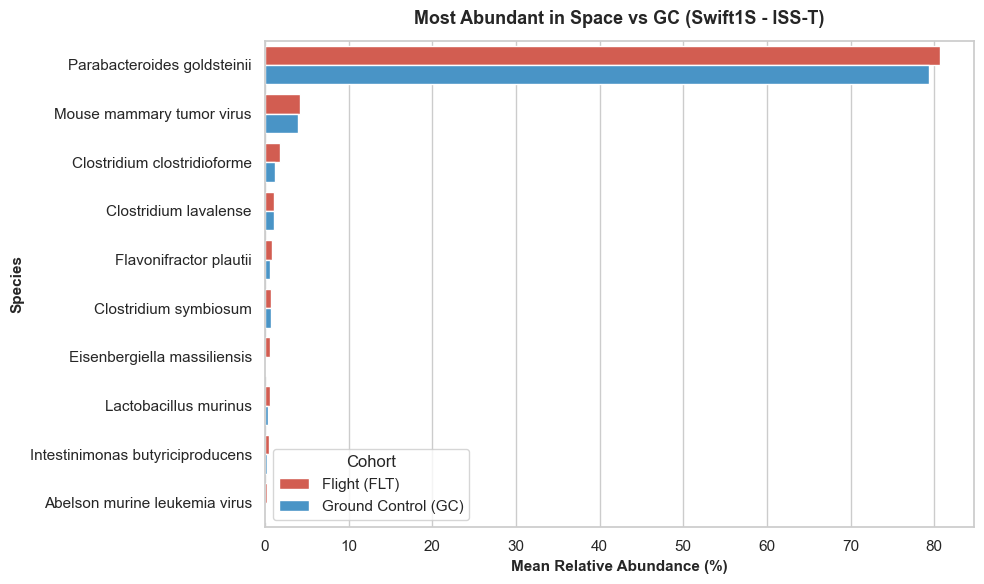

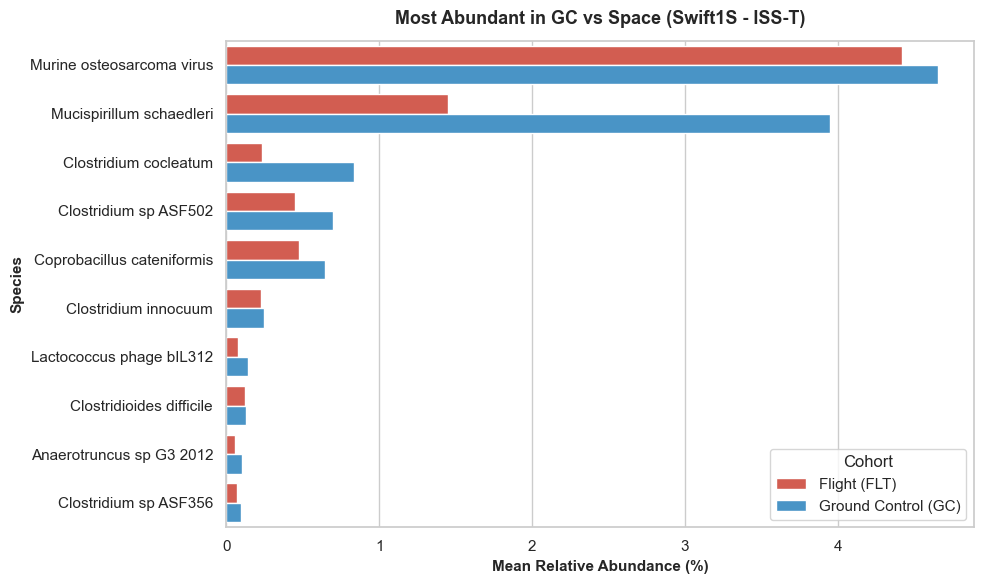

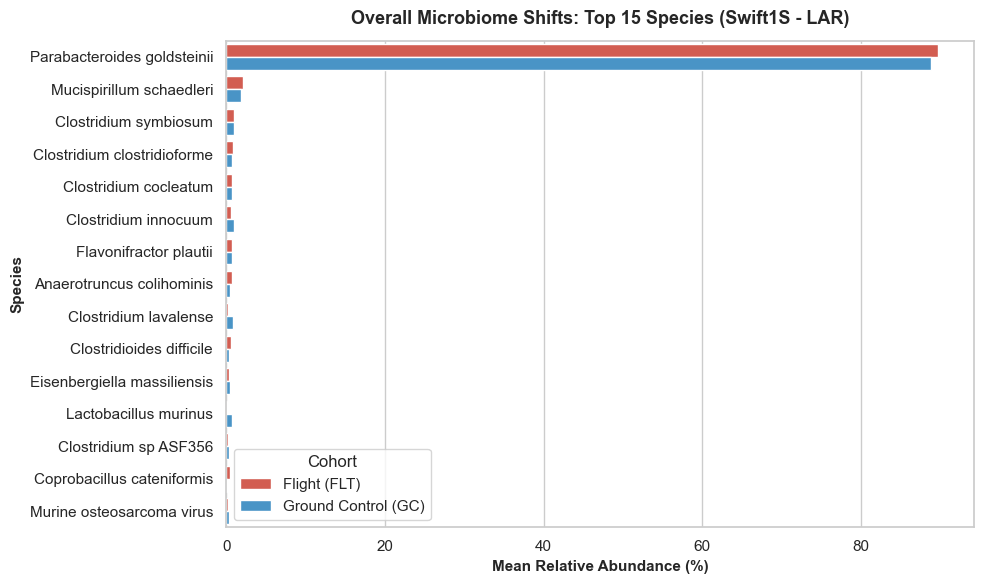

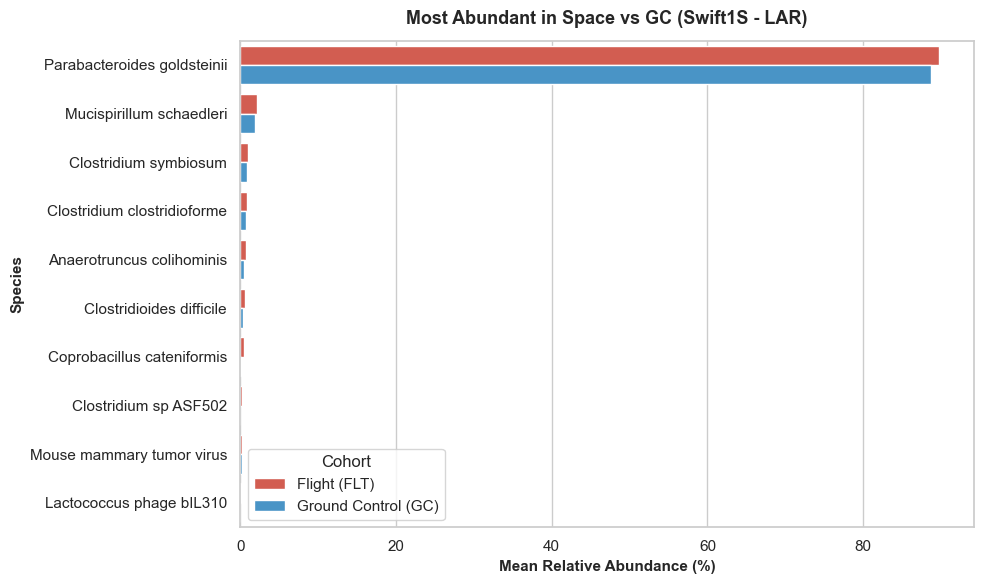

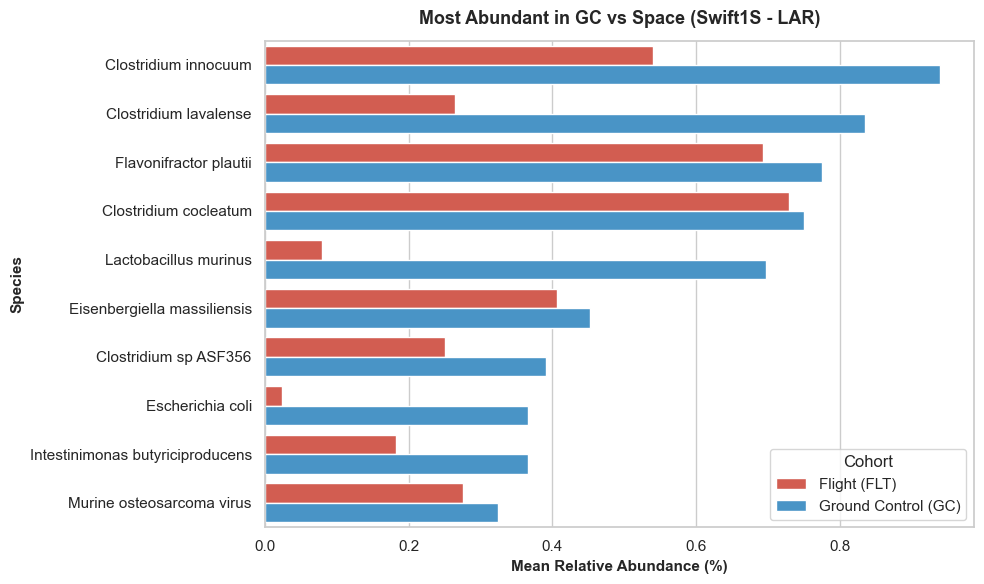

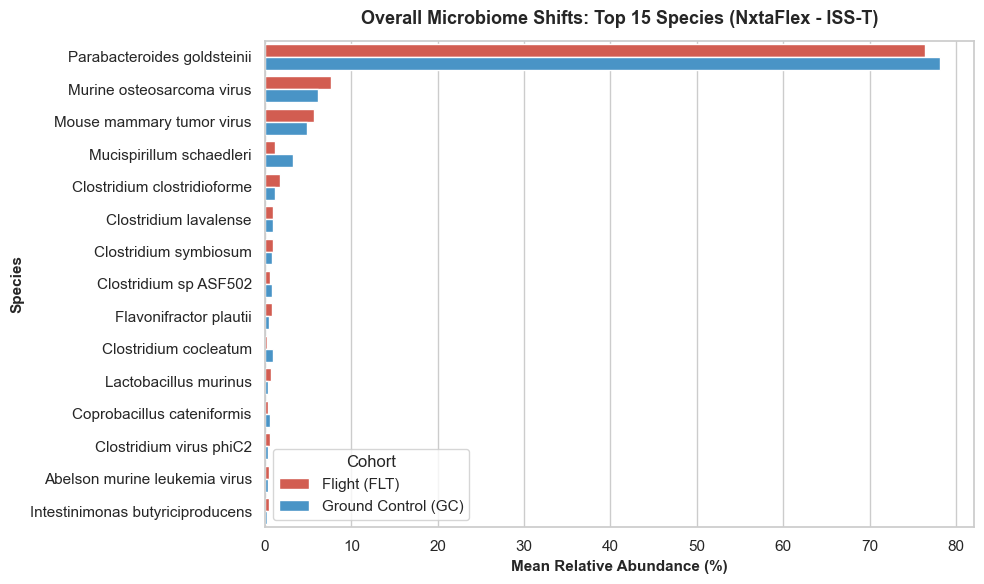

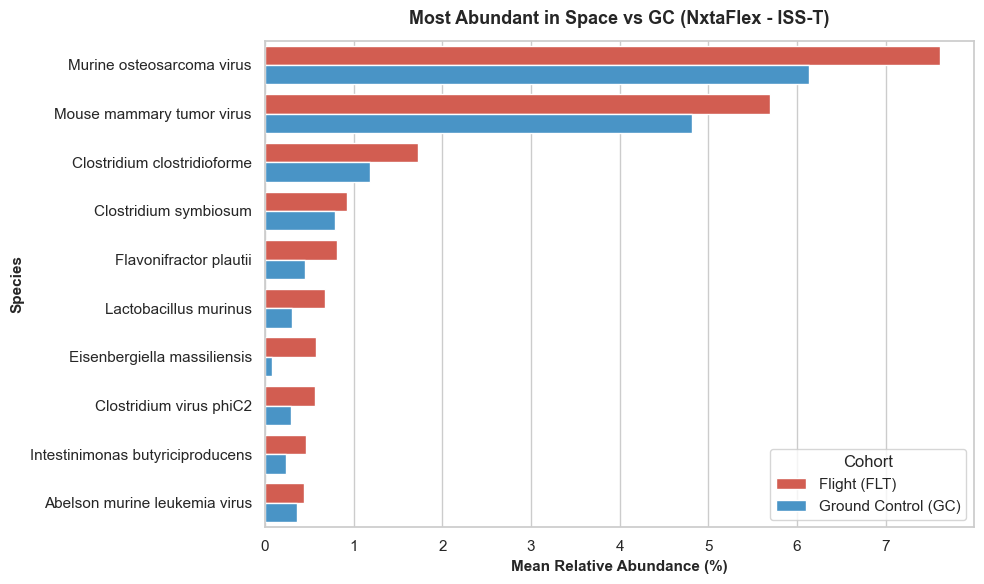

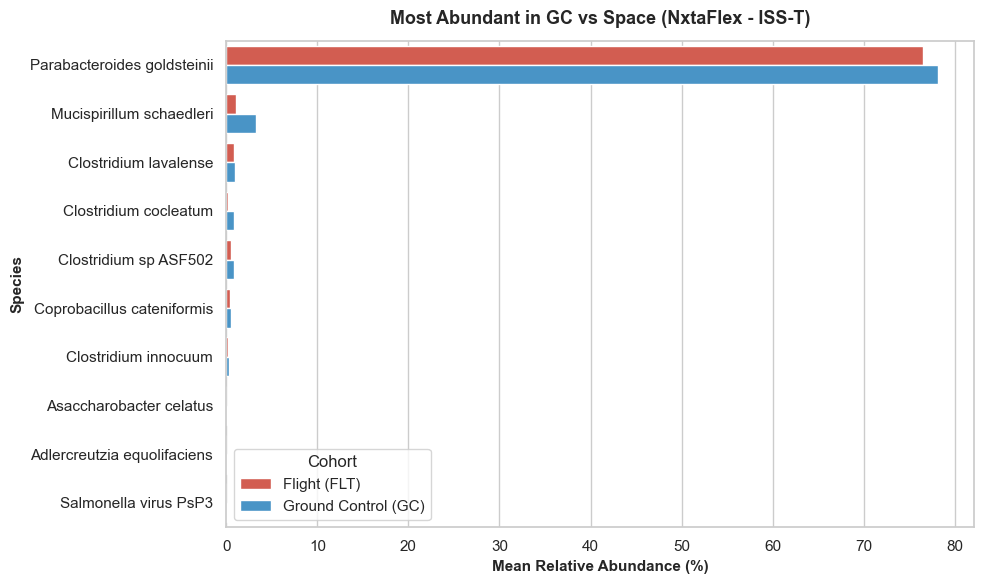

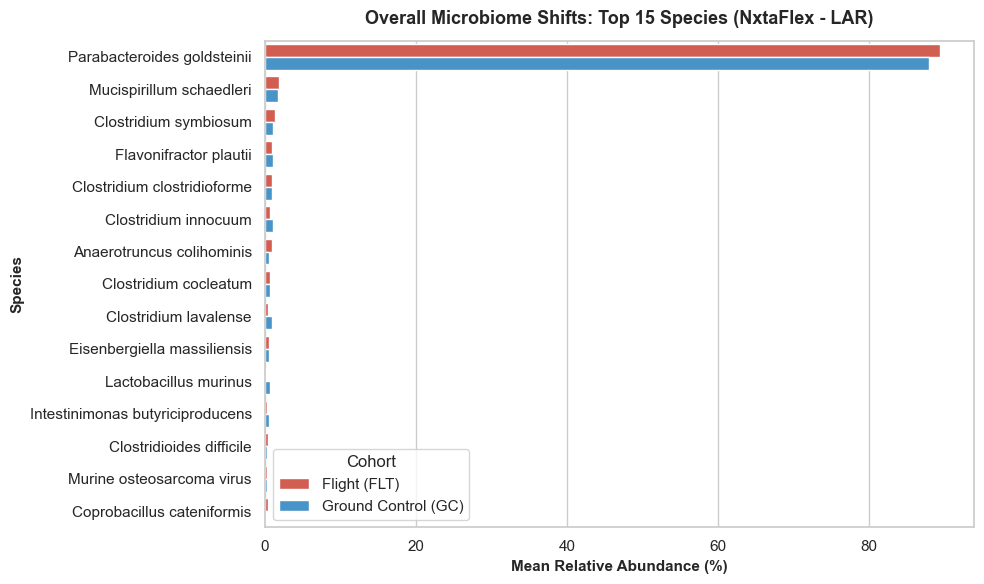

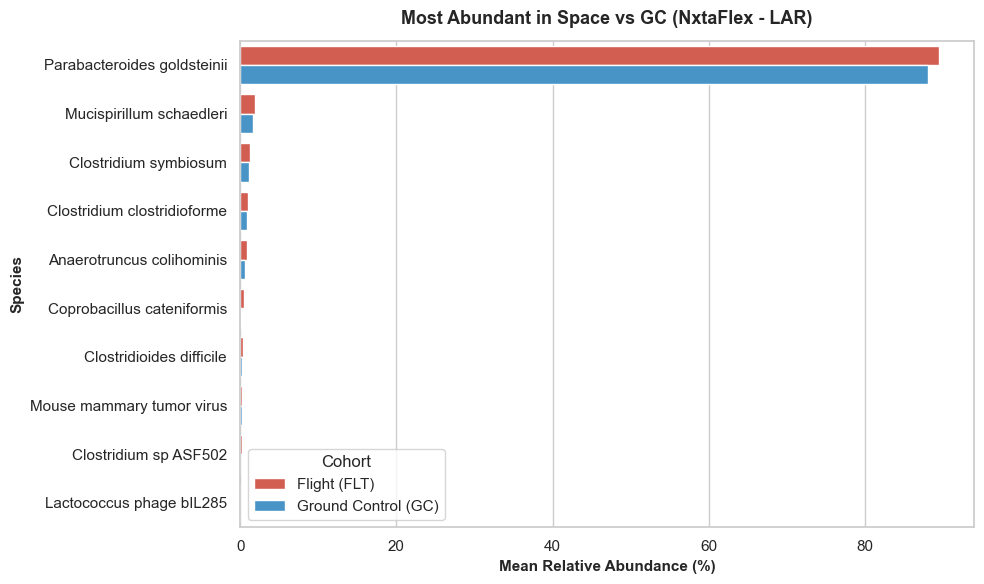

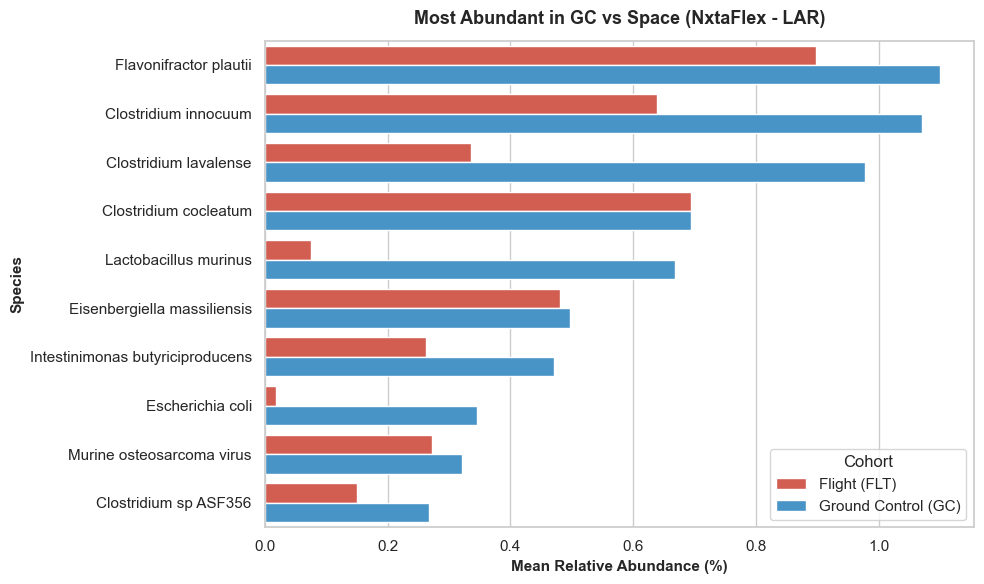

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# DEFINE TARGET ANALYSIS FOLDER
# Set this to the exact name or path of your OSD-249 analysis directory
# ==============================================================================
output_folder = "OSD-249_Analysis_Outputs"  # <-- Change this if your folder path is different

# Ensure the output directory exists
os.makedirs(output_folder, exist_ok=True)

def generate_microbiome_plots(df, tech, mission, save_directory):
    """
    Generates 3 comparative graphs per technology & mission combination and
    saves them directly into the designated OSD-249 analysis folder.
    """
    sns.set_theme(style="whitegrid")
    flt_color = "#e74c3c"  # Crimson Red for Spaceflight (FLT)
    gc_color = "#3498db"   # Soft Blue for Ground Control (GC)
    palette = {'Flight (FLT)': flt_color, 'Ground Control (GC)': gc_color}

    # -------------------------------------------------------------
    # GRAPH 1: OVERALL SHIFTS (Top 15 species by total mean abundance)
    # -------------------------------------------------------------
    df_overall = df.copy()
    df_overall['Overall_Mean'] = (df_overall['Mean_FLT'] + df_overall['Mean_GC']) / 2
    top_overall = df_overall.sort_values(by='Overall_Mean', ascending=False).head(15)

    df_melted_overall = pd.melt(
        top_overall, 
        id_vars=['Species'], 
        value_vars=['Mean_FLT', 'Mean_GC'], 
        var_name='Group', 
        value_name='Relative_Abundance'
    )
    df_melted_overall['Group'] = df_melted_overall['Group'].map({'Mean_FLT': 'Flight (FLT)', 'Mean_GC': 'Ground Control (GC)'})

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_melted_overall, 
        y='Species', 
        x='Relative_Abundance', 
        hue='Group', 
        palette=palette
    )
    plt.title(f"Overall Microbiome Shifts: Top 15 Species ({tech} - {mission})", fontsize=13, fontweight='bold', pad=12)
    plt.xlabel("Mean Relative Abundance (%)", fontsize=11, fontweight='bold')
    plt.ylabel("Species", fontsize=11, fontweight='bold')
    plt.legend(title="Cohort", frameon=True)
    plt.tight_layout()
    
    # Save to the designated OSD-249 folder
    g1_path = os.path.join(save_directory, f"Graph1_Overall_Shifts_{tech}_{mission}.png")
    plt.savefig(g1_path, dpi=300)
    plt.show()
    plt.close()

    # -------------------------------------------------------------
    # GRAPH 2: MOST ABUNDANT IN SPACE VS GC (Top 10 enriched in FLT)
    # -------------------------------------------------------------
    top_flt = df[df['Mean_FLT'] > df['Mean_GC']].sort_values(by='Mean_FLT', ascending=False).head(10)
    if not top_flt.empty:
        df_melted_flt = pd.melt(
            top_flt, 
            id_vars=['Species'], 
            value_vars=['Mean_FLT', 'Mean_GC'], 
            var_name='Group', 
            value_name='Relative_Abundance'
        )
        df_melted_flt['Group'] = df_melted_flt['Group'].map({'Mean_FLT': 'Flight (FLT)', 'Mean_GC': 'Ground Control (GC)'})

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=df_melted_flt, 
            y='Species', 
            x='Relative_Abundance', 
            hue='Group', 
            palette=palette
        )
        plt.title(f"Most Abundant in Space vs GC ({tech} - {mission})", fontsize=13, fontweight='bold', pad=12)
        plt.xlabel("Mean Relative Abundance (%)", fontsize=11, fontweight='bold')
        plt.ylabel("Species", fontsize=11, fontweight='bold')
        plt.legend(title="Cohort", frameon=True)
        plt.tight_layout()
        
        # Save to the designated OSD-249 folder
        g2_path = os.path.join(save_directory, f"Graph2_Most_Abundant_Space_{tech}_{mission}.png")
        plt.savefig(g2_path, dpi=300)
        plt.show()
        plt.close()

    # -------------------------------------------------------------
    # GRAPH 3: MOST ABUNDANT IN GC VS SPACE (Top 10 enriched in GC)
    # -------------------------------------------------------------
    top_gc = df[df['Mean_GC'] > df['Mean_FLT']].sort_values(by='Mean_GC', ascending=False).head(10)
    if not top_gc.empty:
        df_melted_gc = pd.melt(
            top_gc, 
            id_vars=['Species'], 
            value_vars=['Mean_FLT', 'Mean_GC'], 
            var_name='Group', 
            value_name='Relative_Abundance'
        )
        df_melted_gc['Group'] = df_melted_gc['Group'].map({'Mean_FLT': 'Flight (FLT)', 'Mean_GC': 'Ground Control (GC)'})

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=df_melted_gc, 
            y='Species', 
            x='Relative_Abundance', 
            hue='Group', 
            palette=palette
        )
        plt.title(f"Most Abundant in GC vs Space ({tech} - {mission})", fontsize=13, fontweight='bold', pad=12)
        plt.xlabel("Mean Relative Abundance (%)", fontsize=11, fontweight='bold')
        plt.ylabel("Species", fontsize=11, fontweight='bold')
        plt.legend(title="Cohort", frameon=True)
        plt.tight_layout()
        
        # Save to the designated OSD-249 folder
        g3_path = os.path.join(save_directory, f"Graph3_Most_Abundant_GC_{tech}_{mission}.png")
        plt.savefig(g3_path, dpi=300)
        plt.show()
        plt.close()


# Execution Loop across 2 Technologies and 2 Missions
technologies = ['Swift1S', 'NxtaFlex']
missions = ['ISS-T', 'LAR']

for tech in technologies:
    for mission in missions:
        file_name = f"OSD-249_Analysis_Outputs/OSD-249_{tech}_{mission}_Differential_Abundance.csv"
        
        # Check for input file in current directory or target folder
        path_in_curr = file_name
        path_in_folder = os.path.join(output_folder, file_name)
        
        if os.path.exists(path_in_folder):
            df_cohort = pd.read_csv(path_in_folder)
            generate_microbiome_plots(df_cohort, tech, mission, output_folder)
        elif os.path.exists(path_in_curr):
            df_cohort = pd.read_csv(path_in_curr)
            generate_microbiome_plots(df_cohort, tech, mission, output_folder)
        else:
            print(f"Warning: Could not find dataset for {tech} {mission}")